In [1]:
COUNTRIES = {
    'Belgium': [(2000, 2012), (2014, 2024)],
    'Germany': [(2000, 2012), (2014, 2024)], #very low data coverage
    'Italy': [(2000, 2012), (2014, 2024)],
    'Portugal': [None, (2014, 2024)], #no data for first period
    'Spain':[(2000, 2012), (2014, 2024)],
    'Sweden': [(2000, 2012), (2014, 2024)]

}

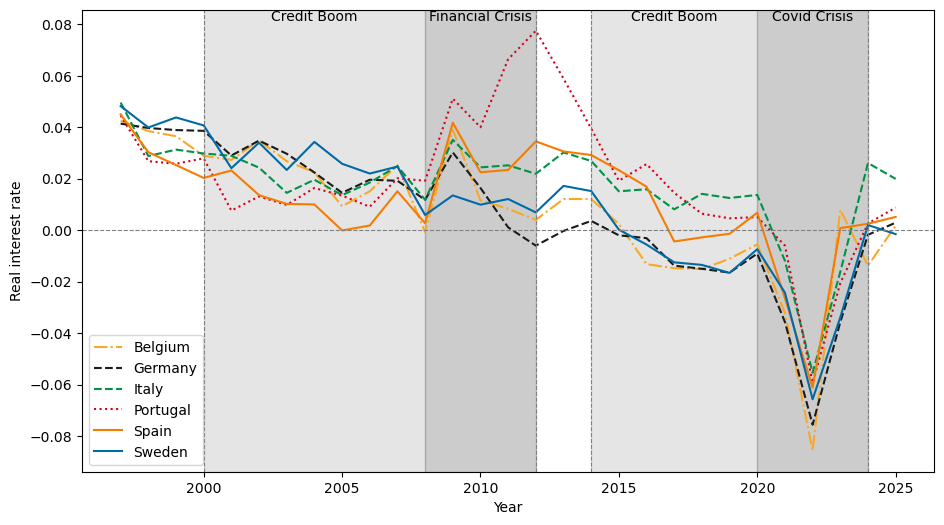

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from modules.RealRate import RealRate
from CompareCountries import COUNTRY_STYLES

df = pd.DataFrame()
for country in COUNTRIES.keys():
    rr = RealRate(country)
    df = pd.concat([df, rr.df], axis=0, ignore_index=True)



fig, ax = plt.subplots(figsize=(11, 6))

for country, g in df.groupby('country'):
    color = COUNTRY_STYLES.get(country)['color']
    linestyle = COUNTRY_STYLES.get(country)['linestyle']
    ax.plot(g['year'], g['realinterestrate'], color=color, label=country, linestyle=linestyle)

ax.axvline(2000, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(2012, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(2014, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(2024, color='grey', linewidth=0.8, linestyle='--')

ax.axvspan(2000, 2008, color='gray', alpha=0.2)
ax.text((2000 + 2008) / 2, ax.get_ylim()[1], 'Credit Boom', ha='center', va='top')

ax.axvspan(2008, 2012, color='gray', alpha=0.4)
ax.text((2008 + 2012) / 2, ax.get_ylim()[1], 'Financial Crisis', ha='center', va='top')

ax.axvspan(2014, 2020, color='gray', alpha=0.2)
ax.text((2014 + 2020) / 2, ax.get_ylim()[1], 'Credit Boom', ha='center', va='top')

ax.axvspan(2020, 2024, color='gray', alpha=0.4)
ax.text((2020 + 2024) / 2, ax.get_ylim()[1], 'Covid Crisis', ha='center', va='top')


ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Year')
ax.set_ylabel('Real Interest Rate')
ax.legend()
plt.show()


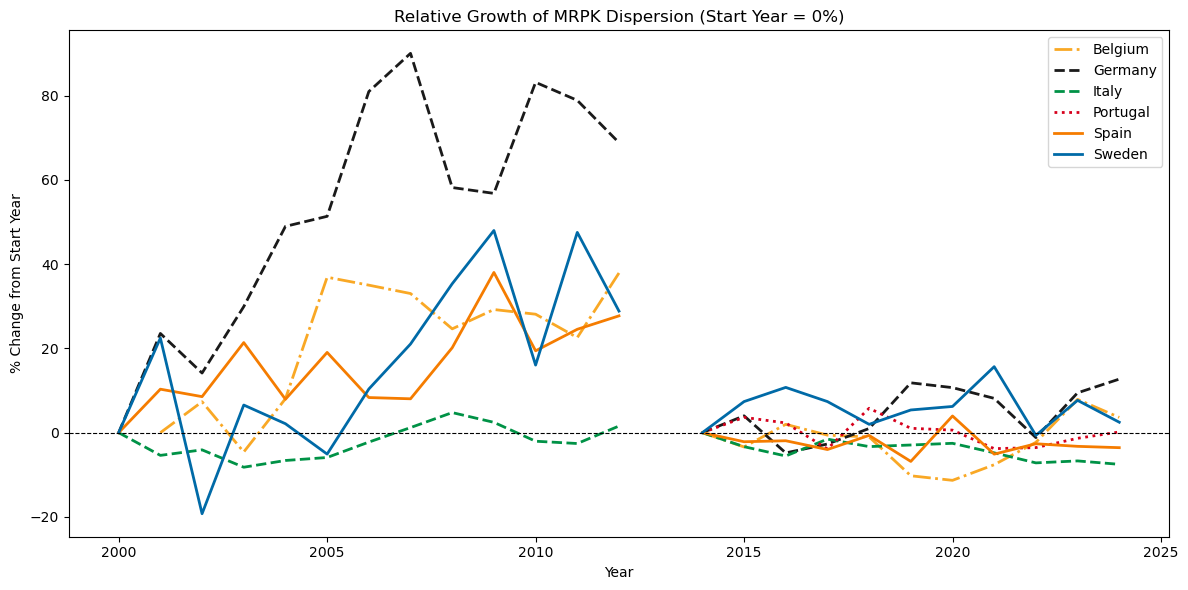

In [3]:
from CompareCountries import CompareCountries
from MisallocationAnalysis import MisallocationAnalysis

allanalises = []

for country, rangelist in COUNTRIES.items():
    for range in rangelist:
        if range == None:
            continue
        analysis = MisallocationAnalysis(country, range[0], range[1], sector='C')
        allanalises.append(analysis)


first_period_comparison = CompareCountries(allanalises)
countriesmrpkplot = first_period_comparison.plot_compare_mrpk()

